In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings

from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")

import joblib

## — CHARGER LE DATASET

In [2]:
df = pd.read_csv('diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2268 entries, 0 to 2267
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2268 non-null   int64  
 1   Glucose                   2268 non-null   int64  
 2   BloodPressure             2268 non-null   int64  
 3   SkinThickness             2268 non-null   int64  
 4   Insulin                   2268 non-null   int64  
 5   BMI                       2268 non-null   float64
 6   DiabetesPedigreeFunction  2268 non-null   float64
 7   Age                       2268 non-null   int64  
 8   Outcome                   2268 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 159.6 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2268.000000,2268.000000,2268.000000,2268.000000,2268.000000,2268.000000,2268.000000,2268.000000,2268.000000
mean,3.610229,120.813051,69.351852,23.847443,111.395062,32.197928,0.474188,33.247795,0.349647
std,3.330855,32.639634,17.691684,15.743663,117.800535,7.676602,0.330265,11.942088,0.476964
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,97.000000,61.000000,13.000000,0.000000,26.900000,0.240000,24.000000,0.000000
50%,3.000000,117.000000,71.000000,25.000000,93.000000,32.100000,0.391500,30.000000,0.000000
75%,6.000000,142.000000,80.000000,35.000000,171.000000,36.900000,0.633750,40.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## — VÉRIFIER LES VALEURS MANQUANTES

In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## — VISUALISATION DES DONNÉES et CORRELATION

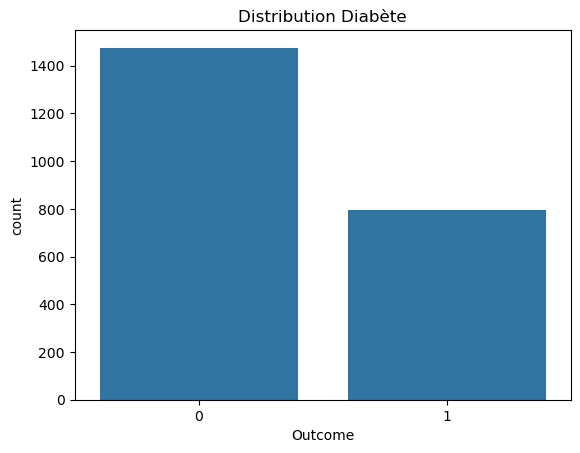

In [7]:
sns.countplot(x='Outcome', data=df)
plt.title("Distribution Diabète")
plt.show()

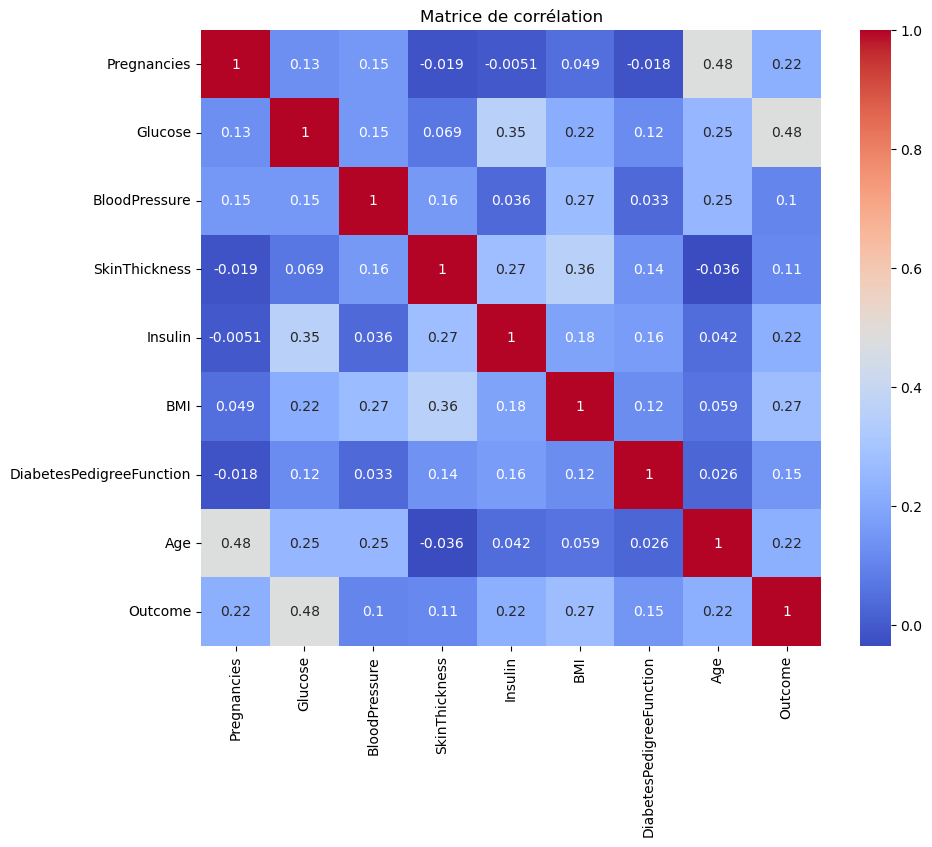

In [8]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Matrice de corrélation")
plt.show()

## — SÉPARER FEATURES ET TARGET

In [9]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## — ENTRAÎNER LE MODÈLE

In [11]:
classifieur_models = {'LogisticRegression':LogisticRegression(),
                    'DecisionTreeClassifier': DecisionTreeClassifier(),
                    'RandomForestClassifier': RandomForestClassifier(n_estimators=100,random_state=42),
                    'SVC': SVC(),
                     'KNeighborsClassifier': KNeighborsClassifier()
                     }

In [12]:
score_train = []
score_test = []
for model in classifieur_models.values():
    model.fit(X_train, y_train)
    score_train.append(model.score(X_train, y_train))
    score_test.append(model.score(X_test, y_test))

modeles = list(classifieur_models.keys())
colonnes = ['Train Score', 'Test Score' ]
df = pd.DataFrame(np.zeros(shape = (len(modeles),2)), columns = colonnes,
                 index = modeles)
df['Train Score'] = score_train
df['Test Score'] = score_test
df.index.name = 'Modeles'
df

,Train Score,Test Score
Modeles,,
LogisticRegression,0.774531,0.773128
DecisionTreeClassifier,1.000000,0.755507
RandomForestClassifier,1.000000,0.823789
SVC,0.776185,0.751101
KNeighborsClassifier,0.840132,0.764317


In [13]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## — FAIRE LES PRÉDICTIONS

In [14]:
y_pred = model.predict(X_test)

## — ÉVALUER LE MODÈLE

In [15]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.8237885462555066


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.93      0.87       290
           1       0.83      0.64      0.72       164

    accuracy                           0.82       454
   macro avg       0.83      0.78      0.80       454
weighted avg       0.82      0.82      0.82       454



##  Matrice de confusion

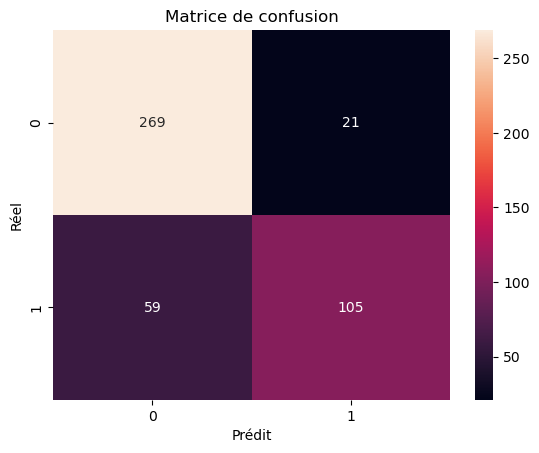

In [17]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")

plt.show()

## — SAUVEGARDER LE MODÈLE

In [18]:
joblib.dump(model, "diabetes_model.pkl")

['diabetes_model.pkl']

## — TESTER LE MODÈLE SAUVEGARDÉ

In [19]:
loaded_model = joblib.load("diabetes_model.pkl")

In [20]:
sample_data = np.array([[2,120,70,20,79,25.0,0.5,33]])

prediction = loaded_model.predict(sample_data)

print(prediction)

[0]
